# Phase 1 - Dataset Discovery for a Conversational Financial Advice Chatbot

**Goal:** Explore and catalog candidate datasets suitable for a *natural-language financial Q&A / advice chatbot*
(general finance Q&A pairs, personal-finance forum Q&A, financial-literacy / conceptual explanations such as
ETFs, compound interest, debt-vs-investing).

**Explicitly out of scope:** any dataset whose primary purpose is *numeric financial profiling*
(salary / income / expense / net-worth / risk-score prediction). This is a **Q&A** chatbot, not an analytics tool.
That class of datasets is listed and **excluded** in §5.

**This phase only:** discovery, source listing, and basic statistics. No cleaning, formatting, or training.
Raw samples are captured *as-is* into `../data/raw/`.

**How to run:** execute the notebook top to bottom. It needs network access to the Hugging Face Hub
(`pip install datasets pandas matplotlib nbformat`).


In [1]:
"""Setup: paths, display options, and imports."""
from __future__ import annotations

import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# Anchor-based: walk up from wherever the kernel started until we find the
# project skeleton (docs/ + data/ + notebooks/). Robust to launch directory.
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if (_cand / "docs").is_dir() and (_cand / "data").is_dir() and (_cand / "notebooks").is_dir():
        PROJECT_ROOT = _cand
        break
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SAMPLE_SIZE = 300  # rows captured per source for data/raw

print("Project root:", PROJECT_ROOT)
print("data/raw directory:", RAW_DIR)

# Selected sources (repo ids on the Hugging Face Hub)
SELECTED_SOURCES = {
    "fingpt-fiqa-qa": "FinGPT/fingpt-fiqa_qa",
    "personal-finance-v2": "Akhil-Theerthala/PersonalFinance_v2",
    "financebench": "PatronusAI/financebench",
}

Project root: C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot
data/raw directory: C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\data\raw


## 1. Candidate catalog

We surveyed public finance NLP datasets and classified each against three eligibility questions:

1. **Right task** - does it provide natural-language *questions* with *answers / advice* (Q&A pairs)?
2. **Right content** - is it about *personal finance / financial literacy / financial concepts* (not numeric profiling)?
3. **Accessible** - can the data be downloaded without gating?

The whole catalog (including excluded items) is built programmatically below. Rows flagged
`profiling` are the **numeric financial profiling** class we explicitly exclude.


In [2]:
"""Build the catalogue as a structured table (reproducible, in-code)."""
catalog_rows = [
    # ---- INCLUDED ----
    {
        "source": "FinGPT/fingpt-fiqa_qa",
        "kind": "General finance Q&A pairs",
        "origin": "FiQA-2018 (StackExchange: Quant. Finance, Crypto)",
        "task": "Financial question answering",
        "size": "~17.1k Q&A pairs",
        "license": "Unspecified on card (derived from FiQA-2018)",
        "status": "INCLUDE",
        "rationale": "Authentic, community-written financial Q&A in instruction format; broad conceptual coverage "
                     "(taxes, business expenses, investing, markets).",
    },
    {
        "source": "Akhil-Theerthala/PersonalFinance_v2",
        "kind": "Personal-finance advice / Q&A",
        "origin": "Reddit r/personalfinance (curated)",
        "task": "Financial advice + reasoning",
        "size": "~7k examples",
        "license": "Apache-2.0",
        "status": "INCLUDE",
        "rationale": "Advice-style Q&A with structured, empathic responses across budgeting, debt, investing, "
                     "retirement, insurance; matches chatbot tone.",
    },
    {
        "source": "PatronusAI/financebench",
        "kind": "Verifiable financial Q&A",
        "origin": "US public company filings (SEC)",
        "task": "Grounding / fact-verifiable QA",
        "size": "150 rows on Hub (full benchmark: 10,231, on request)",
        "license": "CC-BY-NC-4.0",
        "status": "INCLUDE",
        "rationale": "Expert-verified questions, answers, and evidence strings; ideal for teaching grounded, "
                     "checkable financial answers.",
    },
    # ---- EXCLUDED: wrong task ----
    {
        "source": "pauri32/fiqa-2018 (default config)",
        "kind": "Financial sentiment analysis",
        "origin": "FiQA-2018 Task 1 (SA)",
        "task": "Aspect-based sentiment",
        "size": "~17k labelled sentences",
        "license": "Unspecified",
        "status": "EXCLUDE",
        "rationale": "Default config is sentiment, not Q&A. The QA task is covered by FinGPT/fingpt-fiqa_qa above.",
    },
    {
        "source": "financial_phrasebank",
        "kind": "Financial sentiment analysis",
        "origin": "Financial PhraseBank (Malo et al.)",
        "task": "Sentence polarity classification",
        "size": "4,845 sentences",
        "license": "research-only",
        "status": "EXCLUDE",
        "rationale": "Sentiment labels, not natural-language Q&A or advice.",
    },
    # ---- EXCLUDED: numeric financial profiling (the explicit exclusion) ----
    {
        "source": "census income / salary prediction family",
        "kind": "Profiling (income prediction)",
        "origin": "UCI Adults etc.",
        "task": "Predict income class (>50k)",
        "size": "various",
        "license": "various",
        "status": "EXCLUDE",
        "rationale": "Primary purpose is numeric salary/income profiling; not Q&A. Explicitly excluded by spec.",
    },
    {
        "source": "credit-score / loan-default-risk family",
        "kind": "Profiling (risk-score prediction)",
        "origin": "Lending Club / German Credit etc.",
        "task": "Predict default / credit-risk score",
        "size": "various",
        "license": "various",
        "status": "EXCLUDE",
        "rationale": "Primary purpose is numeric risk assessment; not Q&A. Explicitly excluded by spec.",
    },
    {
        "source": "expense / net-worth profiling family",
        "kind": "Profiling (spending / net-worth)",
        "origin": "Bank-transaction analytics dumps",
        "task": "Predict expenses or net worth",
        "size": "various",
        "license": "various",
        "status": "EXCLUDE",
        "rationale": "Numeric analytics datasets; not natural-language financial advice.",
    },
    # ---- EXCLUDED: access / format ----
    {
        "source": "DataDump1/personalfinance_reddit",
        "kind": "Personal-finance forum dump",
        "origin": "Reddit r/personalfinance",
        "task": "Q&A threads",
        "size": "large",
        "license": "gated",
        "status": "EXCLUDE",
        "rationale": "Promising content but the dataset is **gated** on the Hub (requires login); not usable unattended.",
    },
    {
        "source": "BeIR/fiqa",
        "kind": "Retrieval benchmark (FiQA)",
        "origin": "FiQA-2018",
        "task": "Passage retrieval",
        "size": "~25k queries",
        "license": "unknown",
        "status": "EXCLUDE",
        "rationale": "Query/document retrieval format, not answer-generation pairs; may be reused for RAG evaluation later.",
    },
]

catalog = pd.DataFrame(catalog_rows)
catalog

,source,kind,origin,task,size,license,status,rationale
0,FinGPT/fingpt-fiqa_qa,General finance Q&A pairs,"FiQA-2018 (StackExchange: Quant. Finance, Crypto)",Financial question answering,~17.1k Q&A pairs,Unspecified on card (derived from FiQA-2018),INCLUDE,"Authentic, community-written financial Q&A in instruction format; broad conceptual coverage (taxes, business expenses, investing, markets)."
1,Akhil-Theerthala/PersonalFinance_v2,Personal-finance advice / Q&A,Reddit r/personalfinance (curated),Financial advice + reasoning,~7k examples,Apache-2.0,INCLUDE,"Advice-style Q&A with structured, empathic responses across budgeting, debt, investing, retirement, insurance; matches chatbot tone."
2,PatronusAI/financebench,Verifiable financial Q&A,US public company filings (SEC),Grounding / fact-verifiable QA,"150 rows on Hub (full benchmark: 10,231, on request)",CC-BY-NC-4.0,INCLUDE,"Expert-verified questions, answers, and evidence strings; ideal for teaching grounded, checkable financial answers."
3,pauri32/fiqa-2018 (default config),Financial sentiment analysis,FiQA-2018 Task 1 (SA),Aspect-based sentiment,~17k labelled sentences,Unspecified,EXCLUDE,"Default config is sentiment, not Q&A. The QA task is covered by FinGPT/fingpt-fiqa_qa above."
4,financial_phrasebank,Financial sentiment analysis,Financial PhraseBank (Malo et al.),Sentence polarity classification,"4,845 sentences",research-only,EXCLUDE,"Sentiment labels, not natural-language Q&A or advice."
5,census income / salary prediction family,Profiling (income prediction),UCI Adults etc.,Predict income class (>50k),various,various,EXCLUDE,Primary purpose is numeric salary/income profiling; not Q&A. Explicitly excluded by spec.
6,credit-score / loan-default-risk family,Profiling (risk-score prediction),Lending Club / German Credit etc.,Predict default / credit-risk score,various,various,EXCLUDE,Primary purpose is numeric risk assessment; not Q&A. Explicitly excluded by spec.
7,expense / net-worth profiling family,Profiling (spending / net-worth),Bank-transaction analytics dumps,Predict expenses or net worth,various,various,EXCLUDE,Numeric analytics datasets; not natural-language financial advice.
8,DataDump1/personalfinance_reddit,Personal-finance forum dump,Reddit r/personalfinance,Q&A threads,large,gated,EXCLUDE,Promising content but the dataset is **gated** on the Hub (requires login); not usable unattended.
9,BeIR/fiqa,Retrieval benchmark (FiQA),FiQA-2018,Passage retrieval,~25k queries,unknown,EXCLUDE,"Query/document retrieval format, not answer-generation pairs; may be reused for RAG evaluation later."


### 3 selected sources (drivers)

| # | Dataset | Why it fits the chatbot |
|---|---------|-------------------------|
| 1 | `FinGPT/fingpt-fiqa_qa` | General finance Q&A pairs (broad conceptual coverage) |
| 2 | `Akhil-Theerthala/PersonalFinance_v2` | Personal-finance **advice** with structured answers |
| 3 | `PatronusAI/financebench` | **Verifiable** financial Q&A with evidence (grounding) |

Together they cover *concepts + advice + verifiable facts* without touching numeric profiling.


In [3]:
"""Guardrail: a profile-keyword pattern used to scan schemas of the included sources below."""
PROFILE_PATTERN = re.compile(
    r"(salary|income|net.?worth|expense|risk.?score|credit.?limit|loan.?amount|debt.?to.?income)", re.I
)
print("Pattern for excluding profiling columns:", PROFILE_PATTERN.pattern)

Pattern for excluding profiling columns: (salary|income|net.?worth|expense|risk.?score|credit.?limit|loan.?amount|debt.?to.?income)


## 2. Source #1 - `FinGPT/fingpt-fiqa_qa` (general finance Q&A, FiQA-2018)

Reformatted FiQA-2018 **QA** task: real questions and answers from the StackExchange *Quantitative Finance*
and *Finance & Investing (crypto)* communities, stored as `instruction` / `input` / `output` triples.
Gives broad coverage of conceptual financial questions.


In [4]:
"""Explore FinGPT/fingpt-fiqa_qa: schema, statistics, samples."""
repo = SELECTED_SOURCES["fingpt-fiqa-qa"]
ds_fiqa = load_dataset(repo, split="train")
df_fiqa = ds_fiqa.to_pandas()

print("Rows:", len(df_fiqa))
print("\nColumns / dtypes:")
print(df_fiqa.dtypes.to_string())
print("\nMissing values per column:")
print(df_fiqa.isna().sum().to_string())
print("\nDuplicate rows:", int(df_fiqa.duplicated().sum()))

print("\nDistinct instruction templates used:")
print(df_fiqa["instruction"].value_counts().to_string())

# text statistics (sample cap for speed)
cap_fiqa = df_fiqa.head(5000).copy()
cap_fiqa["input_chars"] = cap_fiqa["input"].fillna("").str.len()
cap_fiqa["output_words"] = cap_fiqa["output"].fillna("").str.split().str.len()
print("\nQuestion length (chars) - mean / median / max:",
      round(cap_fiqa["input_chars"].mean()), "/", cap_fiqa["input_chars"].median(), "/", cap_fiqa["input_chars"].max())
print("Answer length (words) - mean / median / max:",
      round(cap_fiqa["output_words"].mean()), "/", cap_fiqa["output_words"].median(), "/", cap_fiqa["output_words"].max())

print("\nSample rows:")
df_fiqa.head(3)[["input", "output"]]

Rows: 17110

Columns / dtypes:
input          object
output         object
instruction    object

Missing values per column:
input          0
output         0
instruction    0

Duplicate rows: 0

Distinct instruction templates used:
instruction
Utilize your financial knowledge, give your answer or opinion to the input question or subject . Answer format is not limited.                  3422
Offer your insights or judgment on the input financial query or topic using your financial expertise. Reply as normal question answering        3422
Based on your financial expertise, provide your response or viewpoint on the given financial question or topic. The response format is open.    3422
Share your insights or perspective on the financial matter presented in the input.                                                              3422
Offer your thoughts or opinion on the input financial query or topic using your financial background.                                           3422

Question 

,input,output
0,What is considered a business expense on a business trip?,The IRS Guidance pertaining to the subject. In general the best I can say is your business expense may be deductible. But it depends o...
1,Claiming business expenses for a business with no income,Yes you can claim your business deductions if you are not making any income yet. But first you should decide what structure you want to ...
2,Transferring money from One business checking to another business checking,"You should have separate files for each of the two businesses. The business that transfers money out should ""write check"" in its QB fil..."


## 3. Source #2 - `Akhil-Theerthala/PersonalFinance_v2` (personal-finance advice)

Curated advice Q&A from Reddit r/personalfinance with four columns: `category`, `query`, `chain_of_thought`,
and `response`. Winner-tagged entry in Hugging Face's *Reasoning Datasets Competition*; covers budgeting, debt,
investing, retirement, insurance, taxes, and estate planning.


Rows: 7036

Columns / dtypes:
category            object
query               object
chain_of_thought    object
response            object

Missing values per column:
category            0
query               0
chain_of_thought    0
response            0



Duplicate rows: 0

Topic (category) distribution:
category
Debt Management & Credit            1989
Retirement Planning                 1169
Investing & Wealth Building         1156
Tax Planning & Optimization         1019
Budgeting & Cash Flow Management     986
Insurance & Risk Management          390
Savings & Emergency Funds            259
Estate Planning & Legacy              68


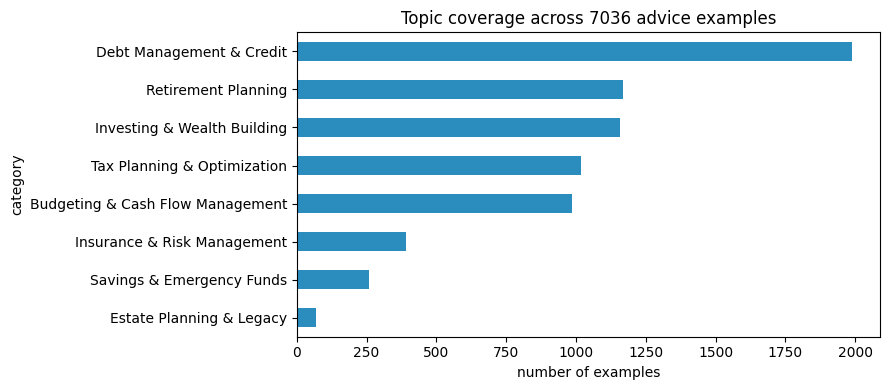


Question length (chars) - mean / median / max: 870 / 691.5 / 6219
Answer length (words) - mean / median / max: 337 / 335.0 / 583
Chain-of-thought length (words) - mean / median / max: 1078 / 1070.0 / 1742

Sample row (truncated):
CATEGORY: Debt Management & Credit
QUERY: "Fixing" a credit account/report I'm trying to help a friend of mine out who has never in his life ever owned a credit card or had a loan in his name or any bills to pay. He got a notice from his ex-wife who apparently filed taxes in his name [...]
RESPONSE: I’m so sorry your friend is dealing with this—it sounds incredibly stressful and frustrating, especially after everything he’s been through. You’re doing a great job helping him navigate this step by step. Here’s how to tackle these issues [...]


In [5]:
"""Explore Akhil-Theerthala/PersonalFinance_v2: schema, category mix, statistics, samples."""
repo = SELECTED_SOURCES["personal-finance-v2"]
ds_pf = load_dataset(repo, split="train")
df_pf = ds_pf.to_pandas()

print("Rows:", len(df_pf))
print("\nColumns / dtypes:")
print(df_pf.dtypes.to_string())
print("\nMissing values per column:")
print(df_pf.isna().sum().to_string())
print("\nDuplicate rows:", int(df_pf.duplicated().sum()))
print("\nTopic (category) distribution:")
print(df_pf["category"].value_counts().to_string())

# category bar chart
fig, ax = plt.subplots(figsize=(9, 4))
counts = df_pf["category"].value_counts()
counts.sort_values().plot.barh(ax=ax, color="#2b8cbe")
ax.set_title(f"Topic coverage across {len(df_pf)} advice examples")
ax.set_xlabel("number of examples")
plt.tight_layout()
plt.show()

cap_pf = df_pf.head(2000).copy()
cap_pf["query_chars"] = cap_pf["query"].fillna("").str.len()
cap_pf["response_words"] = cap_pf["response"].fillna("").str.split().str.len()
cap_pf["cot_words"] = cap_pf["chain_of_thought"].fillna("").str.split().str.len()
print("\nQuestion length (chars) - mean / median / max:",
      round(cap_pf["query_chars"].mean()), "/", cap_pf["query_chars"].median(), "/", cap_pf["query_chars"].max())
print("Answer length (words) - mean / median / max:",
      round(cap_pf["response_words"].mean()), "/", cap_pf["response_words"].median(), "/", cap_pf["response_words"].max())
print("Chain-of-thought length (words) - mean / median / max:",
      round(cap_pf["cot_words"].mean()), "/", cap_pf["cot_words"].median(), "/", cap_pf["cot_words"].max())

print("\nSample row (truncated):")
row = df_pf.iloc[0]
print("CATEGORY:", row["category"])
print("QUERY:", textwrap.shorten(str(row["query"]), width=250))
print("RESPONSE:", textwrap.shorten(str(row["response"]), width=250))

### Guardrail check - no profiling-style columns in the included sources


In [6]:
"""Confirm the three included sources expose no numeric-profiling columns."""
def profile_columns(df):
    hits = [c for c in df.columns if PROFILE_PATTERN.search(c)]
    return hits

all_checks = {
    "FinGPT/fingpt-fiqa_qa": profile_columns(df_fiqa),
    "Akhil-Theerthala/PersonalFinance_v2": profile_columns(df_pf),
}
for source, hits in all_checks.items():
    print(f"{source:<45} profiling-column hits: {hits}")

FinGPT/fingpt-fiqa_qa                         profiling-column hits: []
Akhil-Theerthala/PersonalFinance_v2           profiling-column hits: []


## 4. Source #3 - `PatronusAI/financebench` (verifiable financial Q&A)

The official FinanceBench: expert-annotated `question` / `answer` / `evidence` triplets from US public
company filings. Includes metadata (`company`, `gics_sector`, `question_type`, `question_reasoning`, `doc_type`).
The publicly downloadable Hub file currently contains **150 rows**; the full benchmark (10,231 triplets)
is distributed on request by the authors. Useful for teaching the model to give grounded, checkable answers
rather than made-up numbers.


Rows: 150

Columns / dtypes:
financebench_id         object
company                 object
doc_name                object
question_type           object
question_reasoning      object
domain_question_num     object
question                object
answer                  object
justification           object
dataset_subset_label    object
evidence                object
gics_sector             object
doc_type                object
doc_period               int64
doc_link                object

Missing values per column:
financebench_id           0
company                   0
doc_name                  0
question_type             0
question_reasoning       50
domain_question_num     100
question                  0
answer                    0
justification            50
dataset_subset_label      0
evidence                  0
gics_sector               0
doc_type                  0
doc_period                0
doc_link                  0

Empty-string cells in key text columns:
question         

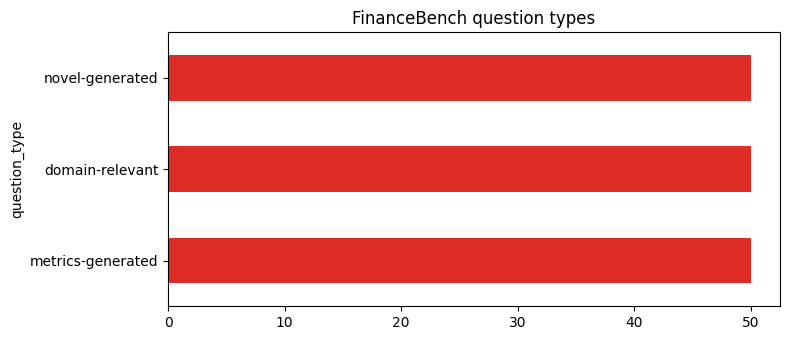


Question length (chars) - mean / median / max: 161 / 137.5 / 592
Answer length (words) - mean / median / max: 13 / 9.0 / 92

Sample rows (question / answer only):


,company,question,answer
0,3M,What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown ...,$1577.00
1,3M,Assume that you are a public equities analyst. Answer the following question by primarily using information that is shown in the balance...,$8.70
2,3M,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio..."


In [7]:
"""Explore PatronusAI/financebench: schema, distributions, samples."""
repo = SELECTED_SOURCES["financebench"]
ds_fb = load_dataset(repo, split="train")
df_fb = ds_fb.to_pandas()

print("Rows:", len(df_fb))
print("\nColumns / dtypes:")
print(df_fb.dtypes.to_string())
print("\nMissing values per column:")
print(df_fb.isna().sum().to_string())

text_cols_fb = ["question", "answer", "justification"]
print("\nEmpty-string cells in key text columns:")
print(df_fb[text_cols_fb].fillna("").eq("").sum().to_string())

print("\nQuestion type distribution:")
print(df_fb["question_type"].value_counts().to_string())
print("\nQuestion reasoning type:")
print(df_fb["question_reasoning"].value_counts().to_string())
print("\nCompany coverage (top 10):")
print(df_fb["company"].value_counts().head(10).to_string())

# bar chart of question types
fig, ax = plt.subplots(figsize=(8, 3.5))
df_fb["question_type"].value_counts().sort_values().plot.barh(ax=ax, color="#de2d26")
ax.set_title("FinanceBench question types")
plt.tight_layout()
plt.show()

cap_fb = df_fb.head(5000).copy()
cap_fb["question_chars"] = cap_fb["question"].fillna("").str.len()
cap_fb["answer_words"] = cap_fb["answer"].fillna("").str.split().str.len()
print("\nQuestion length (chars) - mean / median / max:",
      round(cap_fb["question_chars"].mean()), "/", cap_fb["question_chars"].median(), "/", cap_fb["question_chars"].max())
print("Answer length (words) - mean / median / max:",
      round(cap_fb["answer_words"].mean()), "/", cap_fb["answer_words"].median(), "/", cap_fb["answer_words"].max())

print("\nSample rows (question / answer only):")
df_fb[["company", "question", "answer"]].head(3)

### Guardrail check (continued) - FinanceBench


In [8]:
"""FinanceBench columns are analytic metadata (company/sector/question-type), not profiling targets."""
hits_fb = profile_columns(df_fb)
print("FinanceBench profiling-column hits:", hits_fb)
assert not hits_fb, "Unexpected profiling columns in FinanceBench"

FinanceBench profiling-column hits: []


## 5. Explicitly excluded candidates (incl. numeric-profiling family)

From the catalog above, the following are deliberately **excluded**:

- **Wrong task (sentiment/classification), not Q&A:** `pauri32/fiqa-2018` default config, `financial_phrasebank`.
- **Numeric financial profiling (the spec's explicit exclusion):** census-income / salary predictors,
  credit-risk / loan-default predictors, expense / net-worth analytics. They predict numbers about a person,
  which is the opposite of generating natural-language financial advice.
- **Access / format:** `DataDump1/personalfinance_reddit` (gated), `BeIR/fiqa` (retrieval-only format).

These were *considered* and rejected after inspection - not forgotten.


In [9]:
"""Print the exclusion list captured in the catalog for the record."""
excluded = catalog[catalog["status"] == "EXCLUDE"]
for _, r in excluded.iterrows():
    print(f"- {r['source']:<55} ({r['kind']}) -> {r['rationale']}")

- pauri32/fiqa-2018 (default config)                      (Financial sentiment analysis) -> Default config is sentiment, not Q&A. The QA task is covered by FinGPT/fingpt-fiqa_qa above.
- financial_phrasebank                                    (Financial sentiment analysis) -> Sentiment labels, not natural-language Q&A or advice.
- census income / salary prediction family                (Profiling (income prediction)) -> Primary purpose is numeric salary/income profiling; not Q&A. Explicitly excluded by spec.
- credit-score / loan-default-risk family                 (Profiling (risk-score prediction)) -> Primary purpose is numeric risk assessment; not Q&A. Explicitly excluded by spec.
- expense / net-worth profiling family                    (Profiling (spending / net-worth)) -> Numeric analytics datasets; not natural-language financial advice.
- DataDump1/personalfinance_reddit                        (Personal-finance forum dump) -> Promising content but the dataset is **gated** on the

## 6. Raw sample capture → `data/raw/`

For each selected source we copy a small, **unmodified** slice (first `SAMPLE_SIZE` rows) into
`data/raw/<source>/sample.jsonl`. This is sampling, not cleaning - Phase 2 does the cleaning.


In [10]:
"""Write unmodified sample slices of each selected source into data/raw."""
import os

samples = {
    "fingpt-fiqa-qa/": df_fiqa,
    "personal-finance-v2/": df_pf,
    "financebench/": df_fb,
}

RAW_DIR.mkdir(parents=True, exist_ok=True)
manifest = []
for sub, frame in samples.items():
    out = RAW_DIR / sub
    out.mkdir(parents=True, exist_ok=True)
    frame.head(SAMPLE_SIZE).to_json(out / "sample.jsonl", orient="records", lines=True)
    manifest.append({"source": sub, "file": str(out / "sample.jsonl"),
                     "rows": min(SAMPLE_SIZE, len(frame))})

print("Manifest of captured raw samples:")
for item in manifest:
    size = os.path.getsize(item["file"])
    print(f"  {item['file']}  ({item['rows']} rows, {size/1024:.1f} KiB)")

print("\nDirectory listing of data/raw:")
for p in sorted(RAW_DIR.rglob("*.jsonl")):
    print("  ", p.relative_to(PROJECT_ROOT))

Manifest of captured raw samples:
  C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\data\raw\fingpt-fiqa-qa\sample.jsonl  (300 rows, 332.4 KiB)
  C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\data\raw\personal-finance-v2\sample.jsonl  (300 rows, 3316.8 KiB)
  C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\data\raw\financebench\sample.jsonl  (150 rows, 935.6 KiB)

Directory listing of data/raw:
   data\raw\financebench\sample.jsonl
   data\raw\fingpt-fiqa-qa\sample.jsonl
   data\raw\personal-finance-v2\sample.jsonl


## 7. Summary & next steps

**Chosen sources (3):**

1. `FinGPT/fingpt-fiqa_qa` - general finance Q&A pairs (concepts).
2. `Akhil-Theerthala/PersonalFinance_v2` - personal-finance advice + reasoning (tone).
3. `PatronusAI/financebench` - verifiable financial Q&A with evidence (grounding).

**Excluded:** sentiment benchmarks, retrieval dumps, gated dumps, and the whole *numeric financial profiling*
family (salary / income / expense / net-worth / risk-score prediction).

**Not done here (by design):** cleaning, formatting for instruction tuning, tokenization, training.
Raw samples are in `../data/raw/`. The finalized source list with rationale lives in `../docs/dataset_sources.md`.

**References / source pages**

- <https://huggingface.co/datasets/FinGPT/fingpt-fiqa_qa>
- <https://huggingface.co/datasets/Akhil-Theerthala/PersonalFinance_v2>
- <https://huggingface.co/datasets/PatronusAI/financebench>
- <https://github.com/patronus-ai/financebench>
- FiQA 2018 original site: <https://sites.google.com/view/fiqa/>
